# Assignment 05 - CIFAR-100: Benchmark CNN, VGG, ResNet và DenseNet

Notebook này tải CIFAR-100 từ nguồn chính thức của University of Toronto, kiểm tra MD5 archive, đọc train/test dạng pickle và benchmark bốn kiến trúc CNN compact huấn luyện supervised từ đầu.

## 1. Mục tiêu và phạm vi

CIFAR-100 có 100 lớp fine-grained, gồm 50.000 ảnh train và 10.000 ảnh test, mỗi ảnh màu `32x32`. Notebook split stratified `45.000/5.000` cho train/validation, giữ nguyên 10.000 test, dùng augmentation train-only và đánh giá bốn kiến trúc bằng Accuracy, Macro Precision/Recall/F1, loss, số tham số và thời gian.

## 2. Cấu hình thư viện và seed

Cell này cố định seed, nạp TensorFlow/Keras và các thư viện đánh giá.

In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"

from pathlib import Path
import hashlib
import pickle
import random
import tarfile
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic ops: enabled")
except Exception as exc:
    print("TensorFlow deterministic ops unavailable:", exc)

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.4f}".format
print("TensorFlow:", tf.__version__)

TensorFlow deterministic ops: enabled
TensorFlow: 2.21.0


## 3. CNN như hàm hợp

Với ảnh màu, mỗi convolution nhận tensor `(height, width, channel)` và sinh feature map mới. Chuỗi xử lý vẫn là:

`x -> Convolution -> BatchNorm -> ReLU -> Pooling -> Classifier -> Probability`.

Shape thay đổi theo không gian và số kênh, còn softmax cuối cùng biến logits thành phân phối xác suất 10 lớp.

In [2]:
def conv2d_valid(image, kernel):
    image = np.asarray(image, dtype="float32")
    kernel = np.asarray(kernel, dtype="float32")
    kh, kw = kernel.shape
    out = np.zeros((image.shape[0] - kh + 1, image.shape[1] - kw + 1), dtype="float32")
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(image[i : i + kh, j : j + kw] * kernel)
    return out


def max_pool2d_valid(image, pool_size=2):
    h = (image.shape[0] // pool_size) * pool_size
    w = (image.shape[1] // pool_size) * pool_size
    clipped = image[:h, :w]
    return clipped.reshape(h // pool_size, pool_size, w // pool_size, pool_size).max(axis=(1, 3))


def softmax(logits):
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


x_demo = np.linspace(0, 1, 8 * 8, dtype="float32").reshape(8, 8)
kernel_demo = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype="float32")
conv_demo = conv2d_valid(x_demo, kernel_demo)
bn_demo = (conv_demo - conv_demo.mean()) / (conv_demo.std() + 1e-6)
relu_demo = np.maximum(bn_demo, 0)
pool_demo = max_pool2d_valid(relu_demo, pool_size=2)
flat_demo = pool_demo.reshape(1, -1)
logits_demo = flat_demo @ np.linspace(-0.1, 0.1, flat_demo.shape[1] * 4).reshape(flat_demo.shape[1], 4)
prob_demo = softmax(logits_demo)

display(
    pd.DataFrame(
        [
            ("Input x", x_demo.shape),
            ("Convolution", conv_demo.shape),
            ("BatchNorm", bn_demo.shape),
            ("ReLU", relu_demo.shape),
            ("Pooling", pool_demo.shape),
            ("Flatten", flat_demo.shape),
            ("Softmax probability", prob_demo.shape),
        ],
        columns=["Bước", "Shape"],
    )
)
print("Tổng xác suất:", prob_demo.sum(axis=1))

,Bước,Shape
0,Input x,"(8, 8)"
1,Convolution,"(6, 6)"
2,BatchNorm,"(6, 6)"
3,ReLU,"(6, 6)"
4,Pooling,"(3, 3)"
5,Flatten,"(1, 9)"
6,Softmax probability,"(1, 4)"


Tổng xác suất: [1.]


## 3. Ba hướng phát triển từ CNN

Các kiến trúc dưới đây đều có thể nhìn như những cách khác nhau để thiết kế hàm hợp:

- **VGG**: tăng độ sâu bằng cách chồng nhiều convolution `3x3`: `H(x)=Conv3x3(ReLU(BN(Conv3x3(x))))`.
- **ResNet**: học phần dư thay vì học toàn bộ ánh xạ: `y = ReLU(F(x) + P(x))`, trong đó `P(x)` là phép chiếu `1x1` khi cần đổi số kênh hoặc stride.
- **DenseNet**: mỗi lớp nhận tất cả đặc trưng trước đó: `x_l = H_l([x_0, x_1, ..., x_{l-1}])`.

Trong notebook này, các phiên bản đều là compact và huấn luyện từ đầu, không dùng pretrained.

## 4. Hiện thực kiến trúc Conv2D

Các mô hình dùng cùng code kiến trúc như benchmark ảnh: Basic CNN, Compact VGG, Compact ResNet và Compact DenseNet. Với CIFAR-100, input giữ nguyên `32x32x3`; augmentation gồm horizontal flip, translation, rotation, zoom và contrast nhẹ.

In [3]:
def make_image_preprocessor(mean, std, image_size=None, augment=False, contrast=0.0, name="input_preprocess"):
    preprocess_layers = []
    if image_size is not None:
        preprocess_layers.append(layers.Resizing(image_size, image_size, interpolation="bilinear", name="resize"))
    preprocess_layers.append(layers.Rescaling(1.0 / 255.0, name="rescale_01"))
    if augment:
        preprocess_layers.extend(
            [
                layers.RandomFlip("horizontal", seed=SEED, name="aug_flip"),
                layers.RandomTranslation(0.08, 0.08, fill_mode="nearest", seed=SEED + 1, name="aug_shift"),
                layers.RandomRotation(0.05, fill_mode="nearest", seed=SEED + 2, name="aug_rotate"),
                layers.RandomZoom(0.08, fill_mode="nearest", seed=SEED + 3, name="aug_zoom"),
            ]
        )
        if contrast > 0:
            preprocess_layers.append(layers.RandomContrast(contrast, seed=SEED + 4, name="aug_contrast"))
    mean_tensor = tf.constant(np.asarray(mean, dtype="float32").reshape((1, 1, 1, -1)))
    std_tensor = tf.constant(np.asarray(std, dtype="float32").reshape((1, 1, 1, -1)))
    preprocess_layers.append(layers.Lambda(lambda z: (z - mean_tensor) / std_tensor, name="train_standardization"))
    return tf.keras.Sequential(preprocess_layers, name=name)


def conv2d_bn_relu(x, filters, kernel_size=3, strides=1, name="conv"):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)


def build_basic_cnn(input_shape, num_classes, mean, std, image_size=None, augment=True, contrast=0.0):
    inputs = layers.Input(shape=input_shape)
    x = make_image_preprocessor(mean, std, image_size=image_size, augment=augment, contrast=contrast)(inputs)
    for stage, filters in enumerate([32, 64, 128], start=1):
        x = conv2d_bn_relu(x, filters, name=f"basic_s{stage}")
        x = layers.MaxPooling2D(pool_size=2, name=f"basic_s{stage}_pool")(x)
        x = layers.Dropout(0.15, name=f"basic_s{stage}_dropout")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(128, activation="relu", kernel_initializer="he_normal", name="head_dense")(x)
    x = layers.Dropout(0.35, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probability")(x)
    return models.Model(inputs, outputs, name="basic_cnn")


def build_vgg_compact(input_shape, num_classes, mean, std, image_size=None, augment=True, contrast=0.0):
    inputs = layers.Input(shape=input_shape)
    x = make_image_preprocessor(mean, std, image_size=image_size, augment=augment, contrast=contrast)(inputs)
    for stage, (num_convs, filters) in enumerate(zip([2, 2, 3], [32, 64, 128]), start=1):
        for block in range(1, num_convs + 1):
            x = conv2d_bn_relu(x, filters, name=f"vgg_s{stage}_b{block}")
        x = layers.MaxPooling2D(pool_size=2, name=f"vgg_s{stage}_pool")(x)
        x = layers.Dropout(0.15, name=f"vgg_s{stage}_dropout")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(128, activation="relu", kernel_initializer="he_normal", name="head_dense")(x)
    x = layers.Dropout(0.40, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probability")(x)
    return models.Model(inputs, outputs, name="compact_vgg")


def residual_block_2d(x, filters, stride=1, name="res"):
    shortcut = x
    x = layers.Conv2D(
        filters,
        3,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv1",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv2",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name=f"{name}_proj_conv",
        )(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_proj_bn")(shortcut)
    x = layers.Add(name=f"{name}_add")([x, shortcut])
    return layers.Activation("relu", name=f"{name}_out")(x)


def build_resnet_compact(input_shape, num_classes, mean, std, image_size=None, augment=True, contrast=0.0):
    inputs = layers.Input(shape=input_shape)
    x = make_image_preprocessor(mean, std, image_size=image_size, augment=augment, contrast=contrast)(inputs)
    x = conv2d_bn_relu(x, 32, name="stem")
    for stage, filters in enumerate([32, 64, 128], start=1):
        stride = 1 if stage == 1 else 2
        x = residual_block_2d(x, filters, stride=stride, name=f"res_s{stage}_b1")
        x = residual_block_2d(x, filters, stride=1, name=f"res_s{stage}_b2")
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.35, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probability")(x)
    return models.Model(inputs, outputs, name="compact_resnet")


def dense_layer_2d(x, growth_rate=16, name="dense_layer"):
    y = layers.BatchNormalization(name=f"{name}_bn1")(x)
    y = layers.Activation("relu", name=f"{name}_relu1")(y)
    y = layers.Conv2D(
        growth_rate * 4,
        1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv1",
    )(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)
    y = layers.Activation("relu", name=f"{name}_relu2")(y)
    y = layers.Conv2D(
        growth_rate,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv2",
    )(y)
    return layers.Concatenate(axis=-1, name=f"{name}_concat")([x, y])


def dense_block_2d(x, num_layers, growth_rate=16, name="dense_block"):
    for layer_idx in range(1, num_layers + 1):
        x = dense_layer_2d(x, growth_rate=growth_rate, name=f"{name}_l{layer_idx}")
    return x


def transition_block_2d(x, compression=0.5, name="transition"):
    filters = max(8, int(int(x.shape[-1]) * compression))
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("relu", name=f"{name}_relu")(x)
    x = layers.Conv2D(
        filters,
        1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv",
    )(x)
    return layers.AveragePooling2D(pool_size=2, name=f"{name}_pool")(x)


def build_densenet_compact(input_shape, num_classes, mean, std, image_size=None, augment=True, contrast=0.0):
    inputs = layers.Input(shape=input_shape)
    x = make_image_preprocessor(mean, std, image_size=image_size, augment=augment, contrast=contrast)(inputs)
    x = conv2d_bn_relu(x, 32, name="stem")
    for block_idx, num_layers in enumerate([3, 4, 4], start=1):
        x = dense_block_2d(x, num_layers, growth_rate=16, name=f"dense_b{block_idx}")
        if block_idx < 3:
            x = transition_block_2d(x, compression=0.5, name=f"trans_b{block_idx}")
    x = layers.BatchNormalization(name="final_bn")(x)
    x = layers.Activation("relu", name="final_relu")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.35, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probability")(x)
    return models.Model(inputs, outputs, name="compact_densenet")


MODEL_BUILDERS = [
    ("Basic CNN", build_basic_cnn),
    ("Compact VGG", build_vgg_compact),
    ("Compact ResNet", build_resnet_compact),
    ("Compact DenseNet", build_densenet_compact),
]

## 5. Tải CIFAR-100 và kiểm tra MD5

Notebook tải archive `cifar-100-python.tar.gz` từ nguồn chính thức, kiểm tra MD5 rồi trích xuất ba file cần thiết: `train`, `test` và `meta`. Archive được giữ lại trong thư mục `data` để lần chạy sau không cần tải lại.

In [5]:
def resolve_data_dir():
    candidates = [
        Path.cwd().parent / "data",
        Path.cwd() / "data",
        Path("src/Assignment 05/CIFAR-100/data"),
    ]
    for candidate in candidates:
        if candidate.exists() or "src/Assignment 05" in str(candidate):
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    raise FileNotFoundError("Không tìm thấy thư mục data cho CIFAR-100.")


DATA_DIR = resolve_data_dir()
CIFAR100_URL = "https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz"
CIFAR100_MD5 = "eb9058c3a382ffc7106e4002c42a8d85"
ARCHIVE_NAME = "cifar-100-python.tar.gz"
EXTRACTED_DIR = DATA_DIR / "cifar-100-python"
REQUIRED_FILES = ["train", "test", "meta"]


def md5_file(path, chunk_size=4 * 1024 * 1024):
    digest = hashlib.md5()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def download_with_md5(url, destination, expected_md5):
    if destination.exists() and md5_file(destination) == expected_md5:
        print(f"OK checksum: {destination.name}")
        return destination
    tmp_path = destination.with_suffix(destination.suffix + ".part")
    print(f"Downloading CIFAR-100 archive from {url}")
    urllib.request.urlretrieve(url, tmp_path)
    actual_md5 = md5_file(tmp_path)
    if actual_md5 != expected_md5:
        tmp_path.unlink(missing_ok=True)
        raise ValueError(f"CIFAR-100 MD5 mismatch: {actual_md5} != {expected_md5}")
    tmp_path.replace(destination)
    print(f"Saved {destination}")
    return destination


def ensure_cifar100_files():
    if all((EXTRACTED_DIR / filename).exists() for filename in REQUIRED_FILES):
        print("CIFAR-100 pickle files already exist.")
        return EXTRACTED_DIR
    archive_path = DATA_DIR / ARCHIVE_NAME
    download_with_md5(CIFAR100_URL, archive_path, CIFAR100_MD5)
    print("MD5 OK. Extracting train/test/meta files.")
    expected_members = {f"cifar-100-python/{filename}" for filename in REQUIRED_FILES}
    with tarfile.open(archive_path, "r:gz") as tar:
        selected_members = [member for member in tar.getmembers() if member.name in expected_members]
        if len(selected_members) != len(expected_members):
            found = sorted(member.name for member in selected_members)
            raise FileNotFoundError(f"Không tìm đủ file CIFAR-100 cần thiết trong archive: {found}")
        tar.extractall(DATA_DIR, members=selected_members)
    assert all((EXTRACTED_DIR / filename).exists() for filename in REQUIRED_FILES)
    return EXTRACTED_DIR


CIFAR100_DIR = ensure_cifar100_files()
print("CIFAR-100 data dir:", CIFAR100_DIR)

Saved /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 05/CIFAR-100/data/cifar-100-python.tar.gz
MD5 OK. Extracting train/test/meta files.


/var/folders/t3/f133kfhd7l94x4y1w6sbp_kw0000gn/T/ipykernel_73465/603972205.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR, members=selected_members)


CIFAR-100 data dir: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 05/CIFAR-100/data/cifar-100-python


## 6. Đọc pickle, split stratified và EDA

CIFAR-100 lưu ảnh dưới dạng vector 3.072 phần tử theo thứ tự kênh màu. Sau khi đọc, ảnh được reshape về `(N, 32, 32, 3)`. Split train/validation là `45.000/5.000`; test set 10.000 ảnh giữ nguyên và không tham gia fit preprocessing hay early stopping.

Split: (45000, 32, 32, 3) (5000, 32, 32, 3) (10000, 32, 32, 3)
Mean/std train: [0.50705826 0.48642373 0.4405862 ] [0.26724297 0.25633493 0.27603224]


,class_id,class,train,validation,test
0,0,apple,450,50,100
1,1,aquarium_fish,450,50,100
2,2,baby,450,50,100
3,3,bear,450,50,100
4,4,beaver,450,50,100
5,5,bed,450,50,100
6,6,bee,450,50,100
7,7,beetle,450,50,100
8,8,bicycle,450,50,100
9,9,bottle,450,50,100


Mỗi lớp có số mẫu train/validation/test lần lượt: [np.int64(450)] [np.int64(50)] [np.int64(100)]


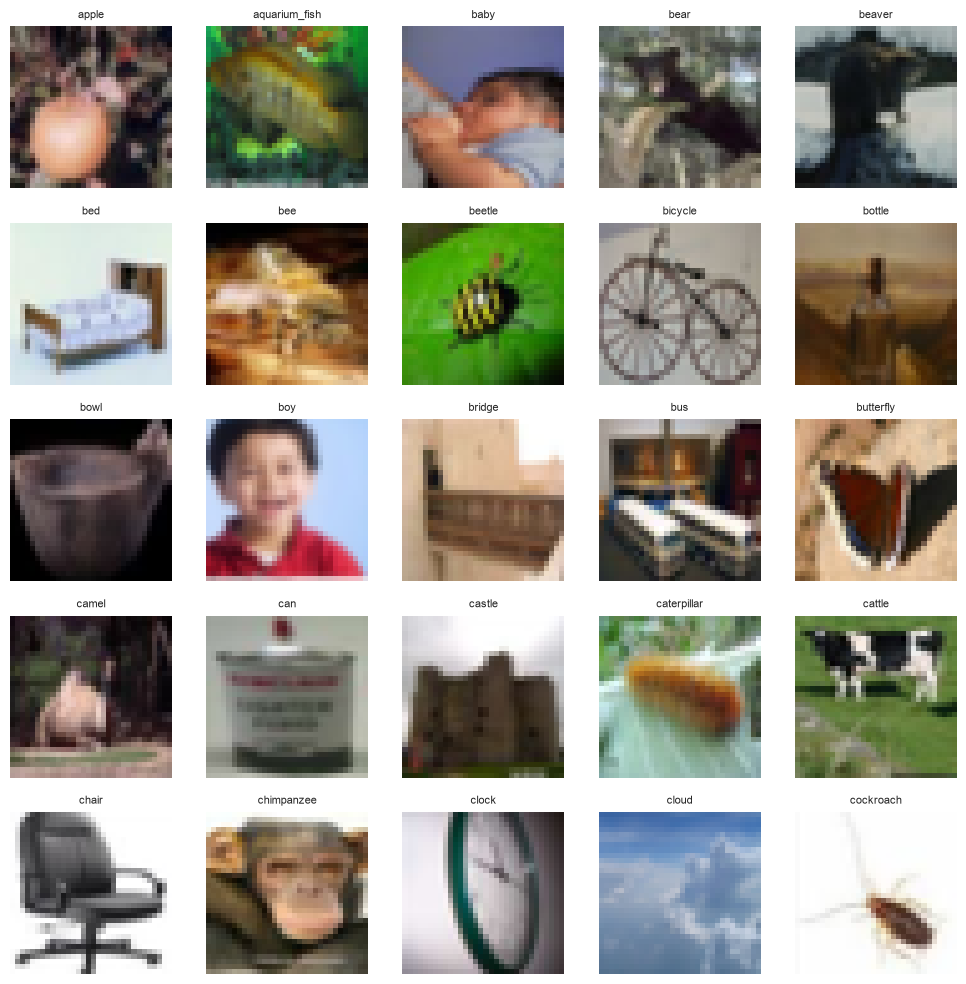

In [6]:
def load_pickle(path):
    with open(path, "rb") as file:
        return pickle.load(file, encoding="latin1")


def cifar100_to_images(flat_data):
    images = np.asarray(flat_data, dtype=np.uint8).reshape(-1, 3, 32, 32)
    return np.transpose(images, (0, 2, 3, 1))


train_obj = load_pickle(CIFAR100_DIR / "train")
test_obj = load_pickle(CIFAR100_DIR / "test")
meta_obj = load_pickle(CIFAR100_DIR / "meta")

CLASS_NAMES = [name.decode("utf-8") if isinstance(name, bytes) else str(name) for name in meta_obj["fine_label_names"]]
NUM_CLASSES = len(CLASS_NAMES)
assert NUM_CLASSES == 100

x_train_full = cifar100_to_images(train_obj["data"])
y_train_full = np.asarray(train_obj["fine_labels"], dtype="int32")
x_test = cifar100_to_images(test_obj["data"])
y_test = np.asarray(test_obj["fine_labels"], dtype="int32")

assert x_train_full.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert set(np.unique(y_train_full)) == set(range(NUM_CLASSES))
assert set(np.unique(y_test)) == set(range(NUM_CLASSES))

full_idx = np.arange(len(x_train_full))
train_idx, val_idx = train_test_split(
    full_idx,
    test_size=5000,
    random_state=SEED,
    stratify=y_train_full,
)
assert set(train_idx).isdisjoint(val_idx)
x_train = x_train_full[train_idx]
y_train = y_train_full[train_idx]
x_val = x_train_full[val_idx]
y_val = y_train_full[val_idx]
assert x_train.shape[0] == 45000 and x_val.shape[0] == 5000

INPUT_SHAPE = x_train.shape[1:]
RESIZE_TO = None
AUG_CONTRAST = 0.10
MAX_EPOCHS = 20
TRAIN_BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 8

train_float = x_train.astype("float32") / 255.0
IMAGE_MEAN = train_float.mean(axis=(0, 1, 2))
IMAGE_STD = train_float.std(axis=(0, 1, 2)) + 1e-6
print("Split:", x_train.shape, x_val.shape, x_test.shape)
print("Mean/std train:", IMAGE_MEAN, IMAGE_STD)

class_distribution = pd.DataFrame(
    {
        "class_id": np.arange(NUM_CLASSES),
        "class": CLASS_NAMES,
        "train": np.bincount(y_train, minlength=NUM_CLASSES),
        "validation": np.bincount(y_val, minlength=NUM_CLASSES),
        "test": np.bincount(y_test, minlength=NUM_CLASSES),
    }
)
display(class_distribution.head(20))
print("Mỗi lớp có số mẫu train/validation/test lần lượt:", sorted(class_distribution["train"].unique()), sorted(class_distribution["validation"].unique()), sorted(class_distribution["test"].unique()))

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for class_id, ax in enumerate(axes.ravel()):
    sample_idx = np.flatnonzero(y_train == class_id)[0]
    ax.imshow(x_train[sample_idx])
    ax.set_title(CLASS_NAMES[class_id], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

del x_train_full, y_train_full, train_float, train_obj, test_obj, meta_obj

## 7. Huấn luyện và đánh giá bốn mô hình

Bốn mô hình dùng cùng split, cùng augmentation train-only, AdamW, `ReduceLROnPlateau` và early stopping. Ảnh CIFAR-100 giữ nguyên kích thước `32x32`, đầu ra softmax có 100 lớp.

In [7]:
EPOCHS = MAX_EPOCHS
BATCH_SIZE = TRAIN_BATCH_SIZE
histories = {}
results = []
test_probabilities = {}
test_predictions = {}
confusion_matrices = {}

for model_name, builder in MODEL_BUILDERS:
    print(f"\n===== {model_name} =====")
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model = builder(
        input_shape=INPUT_SHAPE,
        num_classes=NUM_CLASSES,
        mean=IMAGE_MEAN,
        std=IMAGE_STD,
        image_size=RESIZE_TO,
        augment=True,
        contrast=AUG_CONTRAST,
    )
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1
        ),
    ]
    start = time.perf_counter()
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=2,
    )
    train_time = time.perf_counter() - start
    test_loss, test_acc = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE, verbose=0)
    infer_start = time.perf_counter()
    y_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    inference_time = time.perf_counter() - infer_start
    assert y_prob.shape == (len(y_test), NUM_CLASSES)
    assert np.all(np.isfinite(y_prob))
    assert np.allclose(y_prob.sum(axis=1), 1.0, atol=1e-4)
    y_pred = y_prob.argmax(axis=1)
    assert set(np.unique(y_pred)).issubset(set(range(NUM_CLASSES)))
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(NUM_CLASSES))
    assert cm.shape == (NUM_CLASSES, NUM_CLASSES)
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    results.append(
        {
            "Model": model_name,
            "Accuracy": float(test_acc),
            "Macro Precision": float(precision),
            "Macro Recall": float(recall),
            "Macro F1": float(f1),
            "Test Loss": float(test_loss),
            "Params": int(model.count_params()),
            "Best Epoch": best_epoch,
            "Train Time (s)": float(train_time),
            "Inference Time (s)": float(inference_time),
        }
    )
    histories[model_name] = history.history
    test_probabilities[model_name] = y_prob
    test_predictions[model_name] = y_pred
    confusion_matrices[model_name] = cm
    print(f"{model_name}: params={model.count_params():,}, best_epoch={best_epoch}, test_acc={test_acc:.4f}, macro_f1={f1:.4f}")
    del model

results_df = pd.DataFrame(results).set_index("Model")
assert len(results_df) == 4
assert not results_df.isna().any().any()
display(results_df.sort_values("Macro F1", ascending=False))


===== Basic CNN =====
Epoch 1/20


E0000 00:00:1790279485.545878 3814267 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1790279504.271853 3814267 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

704/704 - 19s - 27ms/step - accuracy: 0.0694 - loss: 4.1227 - val_accuracy: 0.0818 - val_loss: 3.9675 - learning_rate: 0.0010
Epoch 2/20
704/704 - 18s - 26ms/step - accuracy: 0.1274 - loss: 3.6896 - val_accuracy: 0.1090 - val_loss: 3.8010 - learning_rate: 0.0010
Epoch 3/20
704/704 - 19s - 26ms/step - accuracy: 0.1611 - loss: 3.4848 - val_accuracy: 0.1638 - val_loss: 3.5140 - learning_rate: 0.0010
Epoch 4/20
704/704 - 22s - 32ms/step - accuracy: 0.1833 - loss: 3.3522 - val_accuracy: 0.1738 - val_loss: 3.4636 - learning_rate: 0.0010
Epoch 5/20
704/704 - 20s - 28ms/step - accuracy: 0.2020 - loss: 3.2553 - val_accuracy: 0.1868 - val_loss: 3.3647 - learning_rate: 0.0010
Epoch 6/20
704/704 - 17s - 25ms/step - accuracy: 0.2148 - loss: 3.1878 - val_accuracy: 0.1632 - val_loss: 3.6021 - learning_rate: 0.0010
Epoch 7/20
704/704 - 18s - 26ms/step - accuracy: 0.2248 - loss: 3.1283 - val_accuracy: 0.1970 - val_loss: 3.3435 - learning_rate: 0.0010
Epoch 8/20
704/704 - 18s - 25ms/step - accuracy: 0.2

E0000 00:00:1790279859.099498 3814267 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Basic CNN: params=123,332, best_epoch=20, test_acc=0.3156, macro_f1=0.3035

===== Compact VGG =====
Epoch 1/20


...

E0000 00:00:1790282886.371673 3814267 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1790283028.397557 3814267 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

704/704 - 145s - 206ms/step - accuracy: 0.0733 - loss: 4.1084 - val_accuracy: 0.0850 - val_loss: 4.0063 - learning_rate: 0.0010
Epoch 2/20
704/704 - 145s - 206ms/step - accuracy: 0.1262 - loss: 3.6919 - val_accuracy: 0.1252 - val_loss: 3.7404 - learning_rate: 0.0010
Epoch 3/20
704/704 - 151s - 215ms/step - accuracy: 0.1674 - loss: 3.4527 - val_accuracy: 0.1734 - val_loss: 3.5172 - learning_rate: 0.0010
Epoch 4/20
704/704 - 137s - 194ms/step - accuracy: 0.1991 - loss: 3.2661 - val_accuracy: 0.1918 - val_loss: 3.3745 - learning_rate: 0.0010
Epoch 5/20
704/704 - 133s - 189ms/step - accuracy: 0.2272 - loss: 3.1145 - val_accuracy: 0.2040 - val_loss: 3.3853 - learning_rate: 0.0010
Epoch 6/20
704/704 - 139s - 197ms/step - accuracy: 0.2437 - loss: 3.0090 - val_accuracy: 0.2438 - val_loss: 3.1096 - learning_rate: 0.0010
Epoch 7/20
704/704 - 138s - 196ms/step - accuracy: 0.2633 - loss: 2.8988 - val_accuracy: 0.2402 - val_loss: 3.1546 - learning_rate: 0.0010
Epoch 8/20

Epoch 8: ReduceLROnPlateau

E0000 00:00:1790285727.311679 3814267 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1790285733.441934 3814267 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

Compact DenseNet: params=174,564, best_epoch=20, test_acc=0.3796, macro_f1=0.3719


,Accuracy,Macro Precision,Macro Recall,Macro F1,Test Loss,Params,Best Epoch,Train Time (s),Inference Time (s)
Model,,,,,,,,,
Compact ResNet,0.5062,0.5665,0.5062,0.5055,1.8785,710468,20,2018.5737,6.6999
Compact VGG,0.4501,0.5011,0.4501,0.4447,2.1184,465732,20,988.1755,2.5776
Compact DenseNet,0.3796,0.4288,0.3796,0.3719,2.3846,174564,20,2841.0653,6.7352
Basic CNN,0.3156,0.3639,0.3156,0.3035,2.7271,123332,20,373.6567,0.9739


## 8. Learning curves và biểu đồ metric

CIFAR-100 khó hơn Fashion-MNIST vì có 100 lớp fine-grained và mỗi lớp chỉ có 500 ảnh train gốc. Do đó Macro F1 và khoảng cách train/validation rất quan trọng khi đọc kết quả.

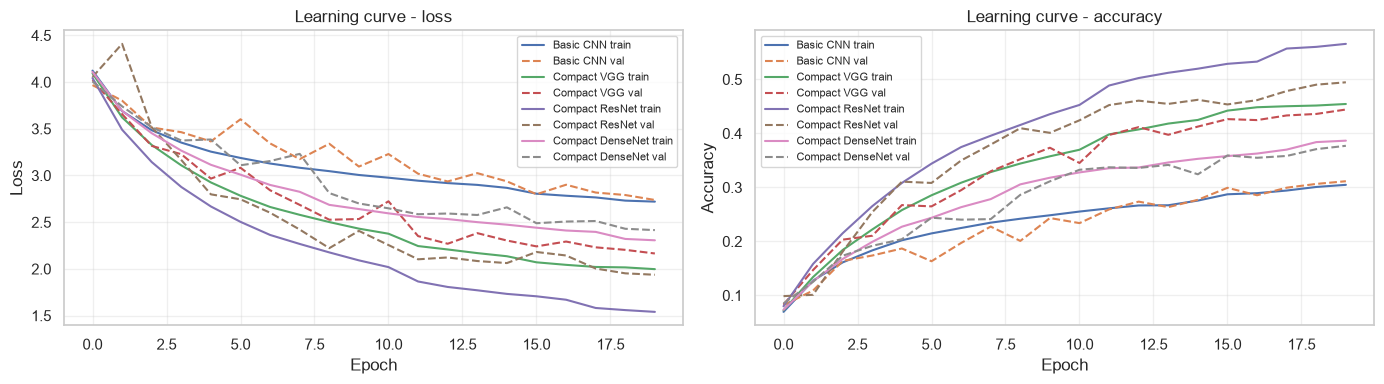

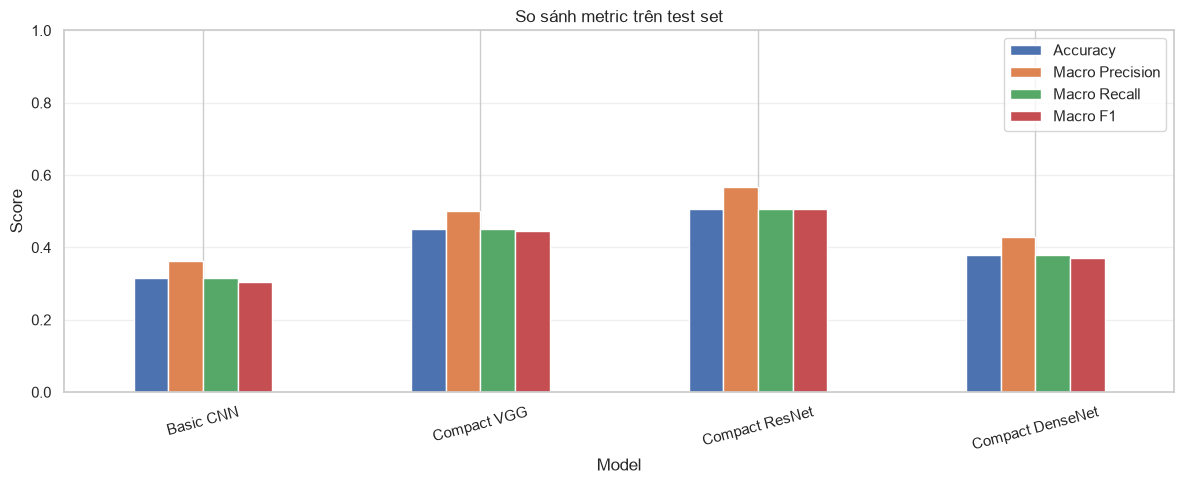

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for model_name, hist in histories.items():
    axes[0].plot(hist["loss"], label=f"{model_name} train")
    axes[0].plot(hist["val_loss"], linestyle="--", label=f"{model_name} val")
    axes[1].plot(hist["accuracy"], label=f"{model_name} train")
    axes[1].plot(hist["val_accuracy"], linestyle="--", label=f"{model_name} val")
axes[0].set_title("Learning curve - loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_title("Learning curve - accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

ax = results_df[["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]].plot(
    kind="bar", figsize=(12, 5), ylim=(0, 1), rot=15
)
ax.set_title("So sánh metric trên test set")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Confusion matrix chuẩn hóa

CIFAR-100 có 100 lớp, do đó mỗi ma trận nhầm lẫn chuẩn hóa có kích thước `100x100`. Vì số lớp lớn, heatmap ẩn nhãn tick để dễ nhìn cấu trúc nhầm lẫn tổng thể.

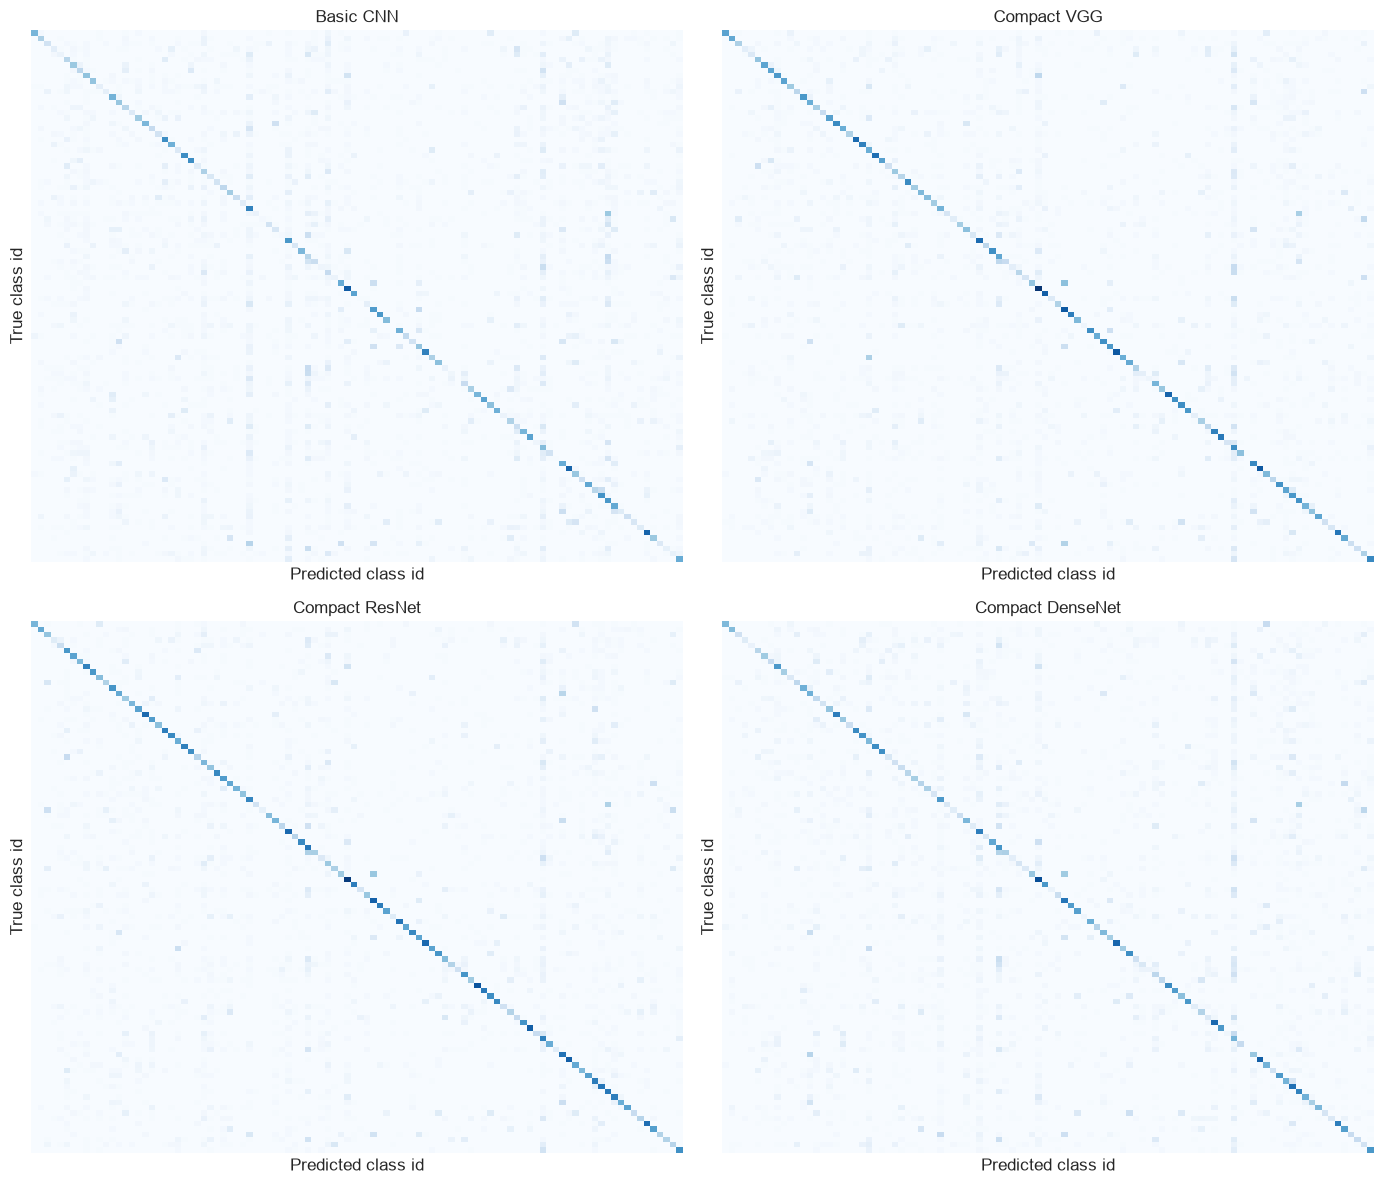

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (model_name, cm) in zip(axes.ravel(), confusion_matrices.items()):
    cm_norm = cm.astype("float32") / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    assert cm_norm.shape == (NUM_CLASSES, NUM_CLASSES)
    sns.heatmap(
        cm_norm,
        ax=ax,
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted class id")
    ax.set_ylabel("True class id")
plt.tight_layout()
plt.show()

## 10. Phân tích lỗi và kết luận tự sinh

Cell cuối xem một số ảnh bị nhầm của mô hình có Macro F1 tốt nhất và sinh kết luận từ số liệu thực tế. Với CIFAR-100, nhiều nhầm lẫn hợp lý sẽ nằm giữa các lớp có ngữ nghĩa/hình dạng gần nhau.

Mô hình tốt nhất theo Macro F1: Compact ResNet
Số ảnh dự đoán sai trên test set: 4938 / 10000


,index,true,pred,confidence
0,0,mountain,bridge,0.6798
1,2,seal,otter,0.1969
2,3,mushroom,table,0.2594
3,5,tulip,spider,0.3635
4,6,camel,tractor,0.3145
5,7,butterfly,beetle,0.2550
6,9,apple,sweet_pepper,0.3687
7,10,sea,bridge,0.5523
8,11,skunk,otter,0.1367
9,21,mountain,keyboard,0.6034


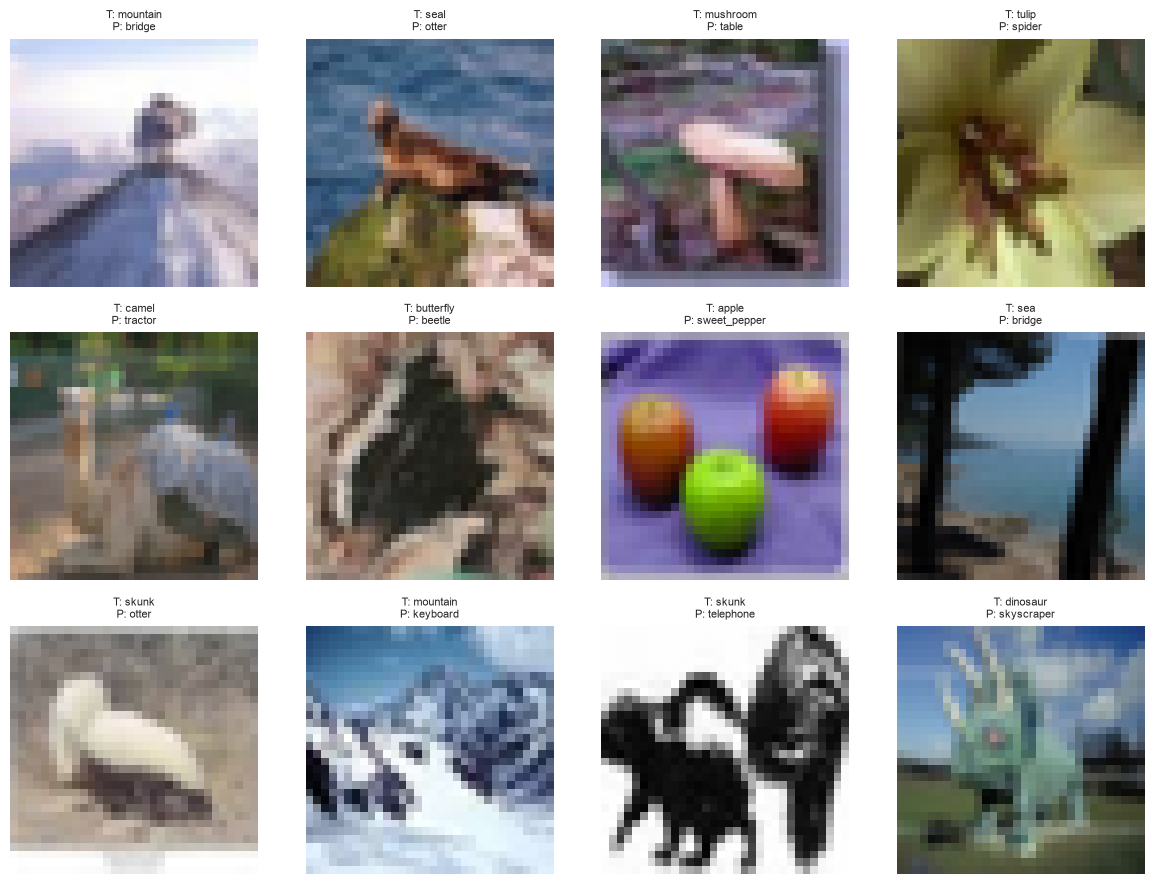

Kết luận: Compact ResNet đạt Macro F1 cao nhất (0.5055) và Compact ResNet đạt accuracy cao nhất (0.5062). Basic CNN có thời gian inference thấp nhất trong lần chạy này. Với CIFAR-100, 100 lớp fine-grained khiến bài toán khó hơn nhiều so với Fashion-MNIST; regularization, augmentation và khả năng truyền gradient của ResNet/DenseNet thường ảnh hưởng rõ tới Macro F1.


In [10]:
best_model_name = results_df["Macro F1"].idxmax()
best_pred = test_predictions[best_model_name]
best_prob = test_probabilities[best_model_name]
wrong_idx = np.flatnonzero(best_pred != y_test)
print(f"Mô hình tốt nhất theo Macro F1: {best_model_name}")
print(f"Số ảnh dự đoán sai trên test set: {len(wrong_idx)} / {len(y_test)}")

error_rows = []
for idx in wrong_idx[:20]:
    error_rows.append(
        {
            "index": int(idx),
            "true": CLASS_NAMES[int(y_test[idx])],
            "pred": CLASS_NAMES[int(best_pred[idx])],
            "confidence": float(best_prob[idx, best_pred[idx]]),
        }
    )
display(pd.DataFrame(error_rows).head(12))

if len(wrong_idx) > 0:
    sample_idx = wrong_idx[:12]
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for ax, idx in zip(axes.ravel(), sample_idx):
        ax.imshow(x_test[idx])
        ax.set_title(
            f"T: {CLASS_NAMES[int(y_test[idx])]}\nP: {CLASS_NAMES[int(best_pred[idx])]}",
            fontsize=8,
        )
        ax.axis("off")
    for ax in axes.ravel()[len(sample_idx):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

best_acc = results_df["Accuracy"].idxmax()
best_f1 = results_df["Macro F1"].idxmax()
fastest = results_df["Inference Time (s)"].idxmin()
print(
    f"Kết luận: {best_f1} đạt Macro F1 cao nhất ({results_df.loc[best_f1, 'Macro F1']:.4f}) "
    f"và {best_acc} đạt accuracy cao nhất ({results_df.loc[best_acc, 'Accuracy']:.4f}). "
    f"{fastest} có thời gian inference thấp nhất trong lần chạy này. "
    "Với CIFAR-100, 100 lớp fine-grained khiến bài toán khó hơn nhiều so với Fashion-MNIST; "
    "regularization, augmentation và khả năng truyền gradient của ResNet/DenseNet thường ảnh hưởng rõ tới Macro F1."
)